In [81]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate simple image

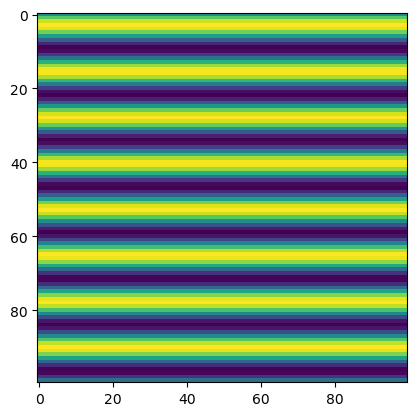

In [247]:
def get_signal(f1, f2, dc=0, amp=1, shift=0.0):
    x = np.linspace(0, 10, 100)
    y = np.linspace(0, 10, 100)

    X, Y = np.meshgrid(x, y)
    z = amp * np.sin(f1 * X + f2 * Y + shift) + dc
    return z
    
z = get_signal(0, 5)
plt.imshow(z)

# 2D fourier is just 2 x 1D fourier
2D fourier impelmented from scratch

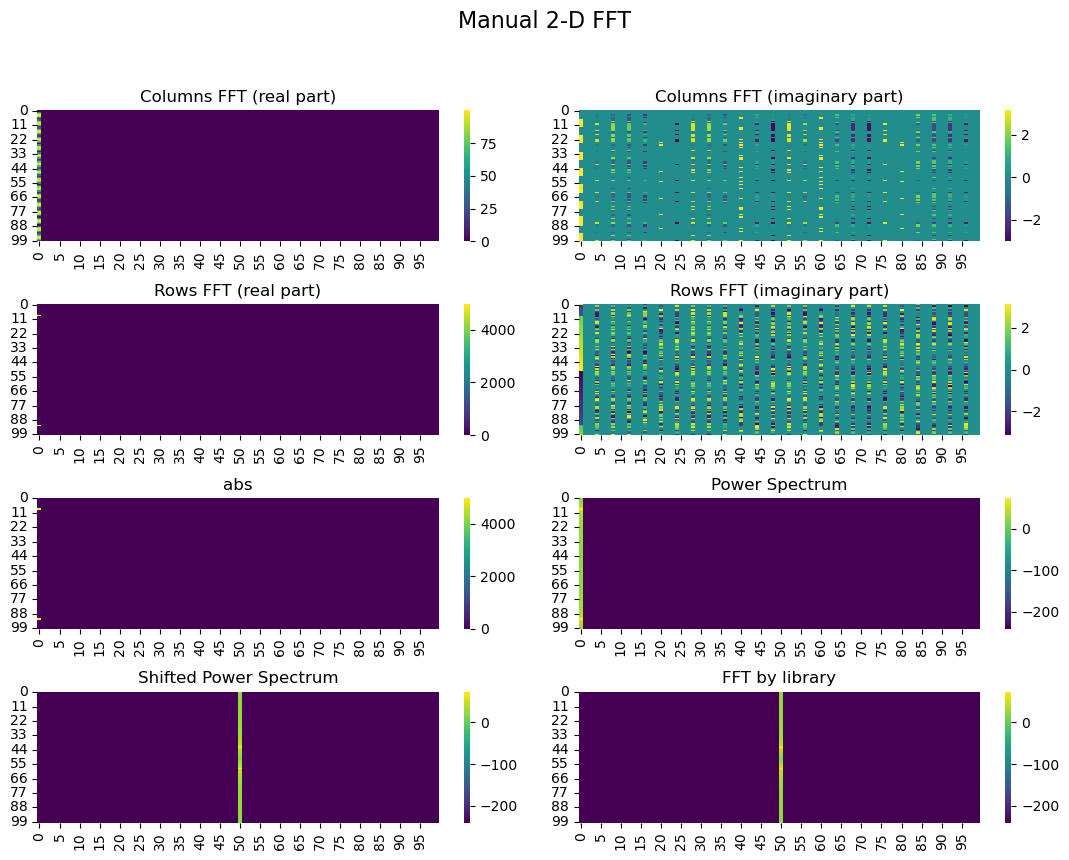

In [ ]:
cols_fft = np.fft.fft(z, axis=1)  # cover cols
F_manual = np.fft.fft(cols_fft, axis=0)  # over rows
FShift = np.fft.fftshift(F_manual)
F_lib = np.fft.fft2(z)

mag1 = np.abs(FShift)

plt.figure(figsize=(11, 9))
plt.suptitle("Manual 2‑D FFT", fontsize=16)

plt.subplot(421)
sns.heatmap(np.abs(cols_fft), cmap='viridis')
plt.title('Columns FFT (real part)')

plt.subplot(422)
sns.heatmap(np.angle(cols_fft), cmap='viridis')
plt.title('Columns FFT (imaginary part)')

plt.subplot(423)
sns.heatmap(np.abs(F_manual), cmap='viridis')
plt.title('Rows FFT (real part)')

plt.subplot(424)
sns.heatmap(np.angle(F_manual), cmap='viridis')
plt.title('Rows FFT (imaginary part)')

plt.subplot(425)
sns.heatmap(np.abs(F_manual), cmap='viridis')
plt.title("abs")

plt.subplot(426)
sns.heatmap(20 * np.log10(np.abs(F_manual + 1e-12)), cmap='viridis')
plt.title("Power Spectrum")

plt.subplot(427)
sns.heatmap(20 * np.log10(np.abs(FShift + 1e-12)), cmap='viridis')
plt.title("Shifted Power Spectrum")

plt.subplot(428)
sns.heatmap(20 * np.log10(np.abs(np.fft.fftshift(F_lib) + 1e-12)), cmap='viridis')
plt.title("FFT by library")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [397]:
z1 = get_signal(12, 0, dc=5, amp=35, shift=0)
z2 = get_signal(12, 0, dc=5, amp=35, shift=4 * np.pi / 4)
# z1 *= 0
# z2 *= 0

# z1[80:80+14, 0:0+14] = 1
# z2[80:80+14, 0:0+14] = 1
# z2[50:50+14, 0:0+14] = 1

mag max: 15.033739974618907 0.0
phase max: 3.117147298570039 -3.141592653589793


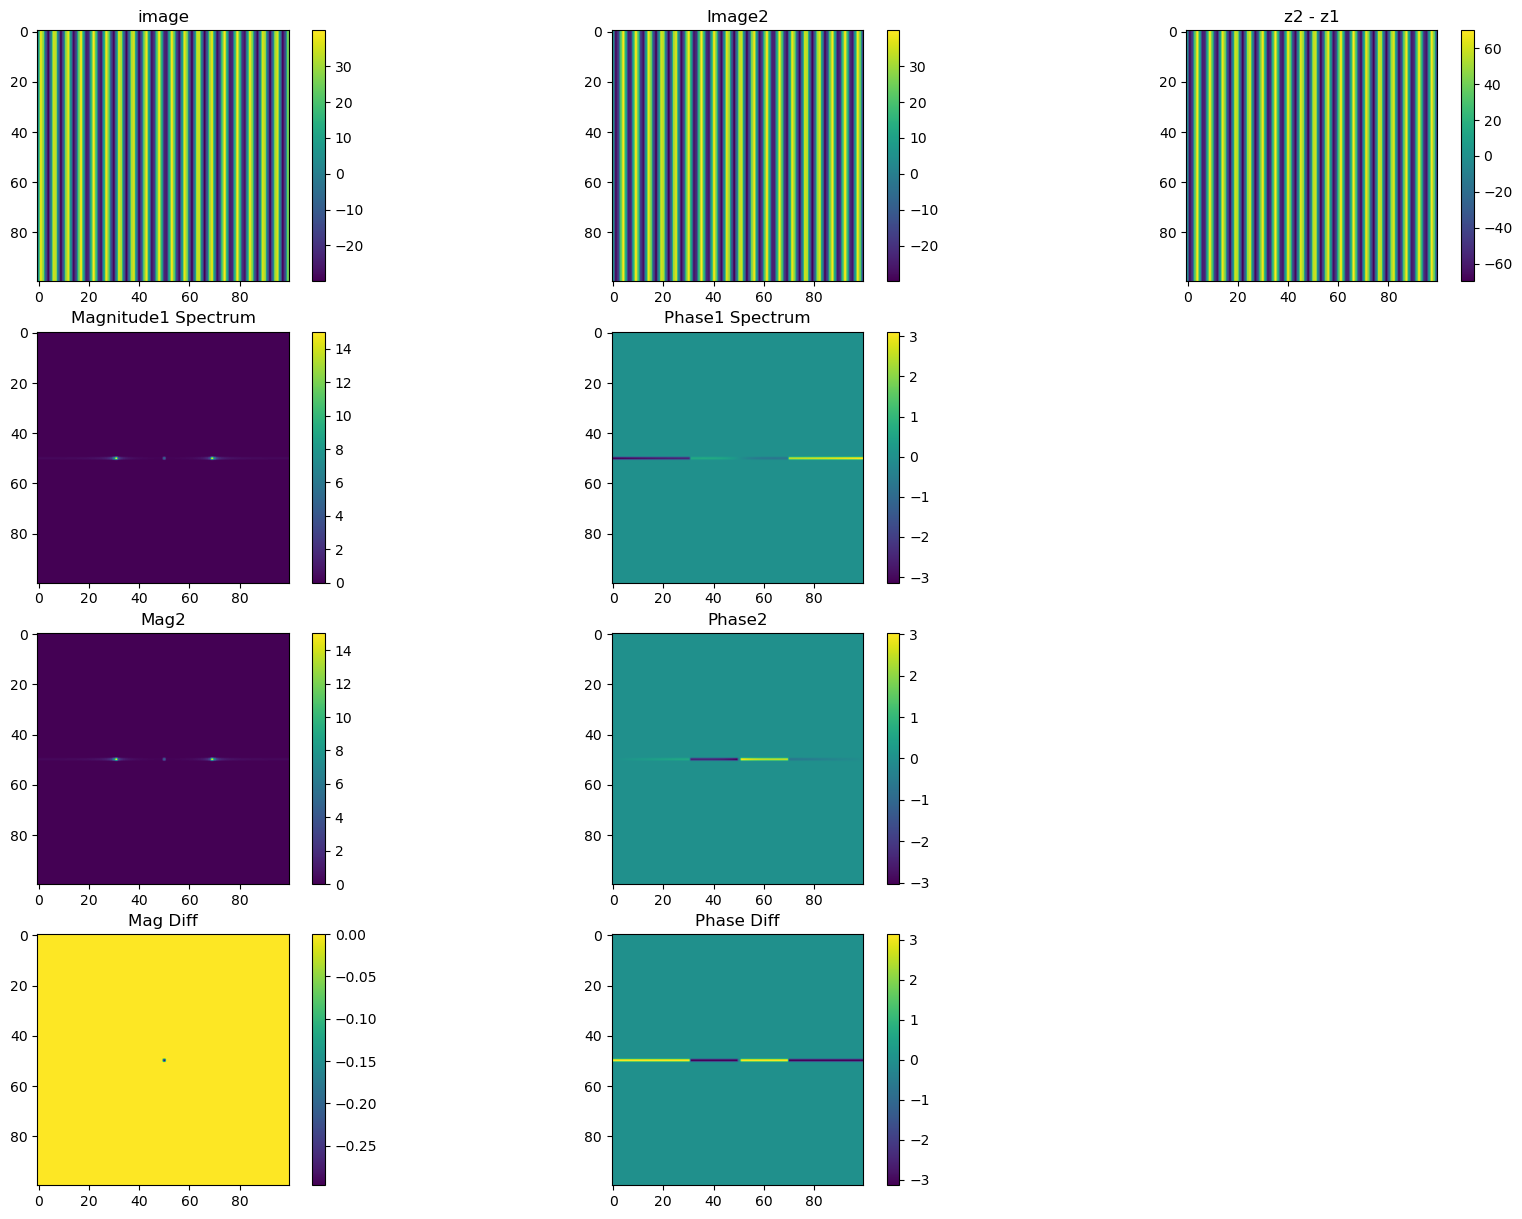

In [398]:
N, M = z.shape

z_padded = np.pad(z1, [20]) # my ultimate weapon hehe, will be unleashed soon >:)
F1 = np.fft.fftshift(np.fft.fft2(z1)) / (N*M)
mag1 = np.abs(F1)
phase1 = np.angle(F1)

F2 = np.fft.fftshift(np.fft.fft2(z2)) / (N*M)
mag2 = np.abs(F2)
phase2 = np.angle(F2)

# Clean up all noise
phase1 = np.where(mag1 > 0.01 * mag1.max(), phase1, 0)
phase2 = np.where(mag2 > 0.01 * mag2.max(), phase2, 0)

plt.figure(figsize=(21, 15))

plt.subplot(431)
plt.imshow(z1)
plt.title("image")
plt.colorbar()

plt.subplot(432)
plt.imshow(z2)
plt.title("Image2")
plt.colorbar()

plt.subplot(433)
plt.imshow(z2 - z1)
plt.title("z2 - z1")

plt.colorbar()
plt.subplot(434)
plt.imshow(mag1)
plt.title("Magnitude1 Spectrum")
plt.colorbar()

plt.subplot(435)
plt.imshow(phase1)
plt.title("Phase1 Spectrum")
plt.colorbar()

plt.subplot(437)
plt.imshow(mag2)
plt.title("Mag2")
plt.colorbar()

plt.subplot(438)
plt.imshow(phase2)
plt.title("Phase2")
plt.colorbar()

plt.subplot(4, 3, 10)
plt.imshow(mag2 - mag1)
plt.title("Mag Diff")
plt.colorbar()

plt.subplot(4, 3, 11)
plt.imshow(phase2 - phase1)
plt.title("Phase Diff")
plt.colorbar()

print(f'mag max: {mag1.max()} {mag1.min()}')
print(f'phase max: {phase1.max()} {phase1.min()}')

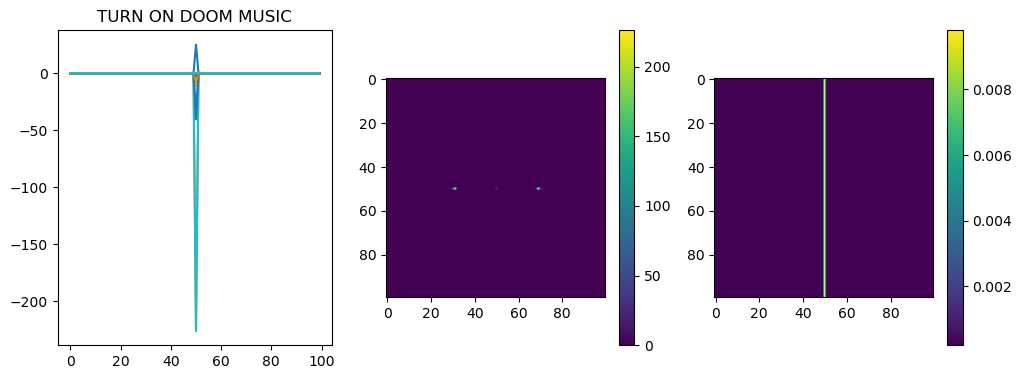

In [399]:
cross_power_spectrum = (F2 * np.conj(F1)) / (np.abs(F2 * np.conj(F1)) + 1e-12)
shift_result = np.fft.ifft2(cross_power_spectrum)
shift_result = np.fft.fftshift(shift_result)

plt.figure(figsize=(12, 9))
rows = 2
cols = 3

plt.subplot(rows, cols, 1)
plt.plot((F2 * np.conj(F1)))
plt.title("TURN ON DOOM MUSIC")

plt.subplot(rows, cols, 2)
plt.imshow(np.abs(F2 * np.conj(F1)))
plt.colorbar()

plt.subplot(rows, cols, 3)
plt.imshow(np.abs(shift_result))
plt.colorbar()

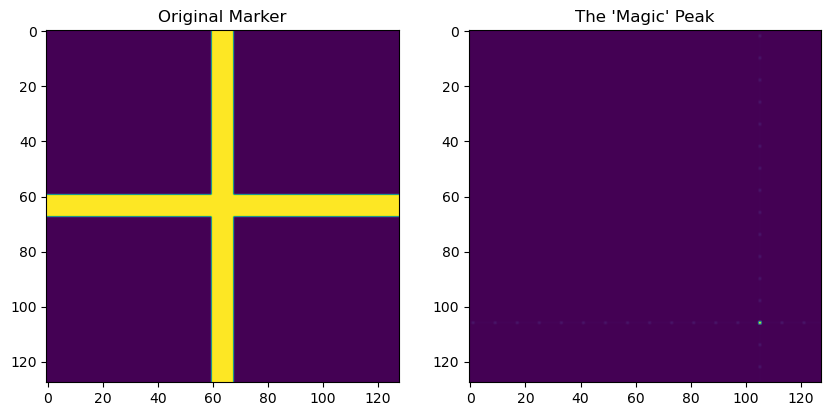

Peak detected at: 41, 42


In [372]:
# 1. Create a "Marker" (A simple cross)
size = 128
img1 = np.zeros((size, size))
img1[60:68, :] = 1  # Horizontal bar
img1[:, 60:68] = 1  # Vertical bar

# 2. Shift the WHOLE IMAGE by exactly 2 pixels in X and 3 in Y
img2 = np.roll(img2_temp := img1.copy(), shift=(42, 41), axis=(0, 1))

# 3. FFTs
F1 = np.fft.fft2(img1)
F2 = np.fft.fft2(img2)

# 4. PHASE CORRELATION (The Industry Way)
# Instead of phase2 - phase1, we do this:
cross_power_spectrum = (F2 * np.conj(F1)) / np.abs(F2 * np.conj(F1) + 1e-12)
shift_result = np.fft.ifft2(cross_power_spectrum)
shift_result = np.fft.fftshift(shift_result) # Put the peak in the middle

# 5. Visualize
plt.figure(figsize=(10, 5))
plt.subplot(121); plt.imshow(img1); plt.title("Original Marker")
plt.subplot(122); plt.imshow(np.abs(shift_result)); plt.title("The 'Magic' Peak")
plt.show()

# Find the peak coordinates
y_peak, x_peak = np.unravel_index(np.argmax(np.abs(shift_result)), shift_result.shape)
print(f"Peak detected at: {x_peak - size//2}, {y_peak - size//2}")